In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import joblib as joblib
import importlib as importlib
import scipy as sp
import qutip as qt

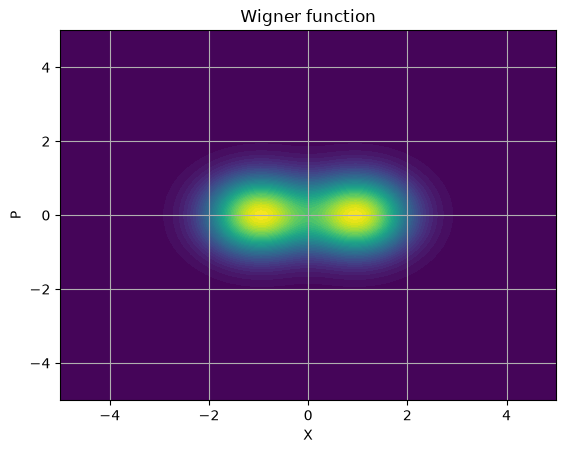

In [2]:
#coherent state from qutip
alpha = 0.7 + 0j
N = 100
coherent_state1 = qt.coherent(N, alpha)
coherent_state2 = qt.coherent(N, -alpha)
#plot in phase space
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()

Minimum error prob
$$
P_H = \cfrac12 \left( 1- \sqrt{1-|\langle\alpha |\beta \rangle|^2} \right)
$$

In [3]:
def min_error_prob(coherent_state1, coherent_state2):
    # Calculate the overlap between the two coherent states
    overlap = np.abs(coherent_state1.overlap(coherent_state2))**2
    # Calculate the minimum error probability using the Helstrom bound
    min_error_prob = 0.5 * (1 - np.sqrt(1 - overlap))
    return min_error_prob
P_H = min_error_prob(coherent_state1, coherent_state2)
print(f'Minimum error probability: {P_H:.4f}')

Minimum error probability: 0.0366


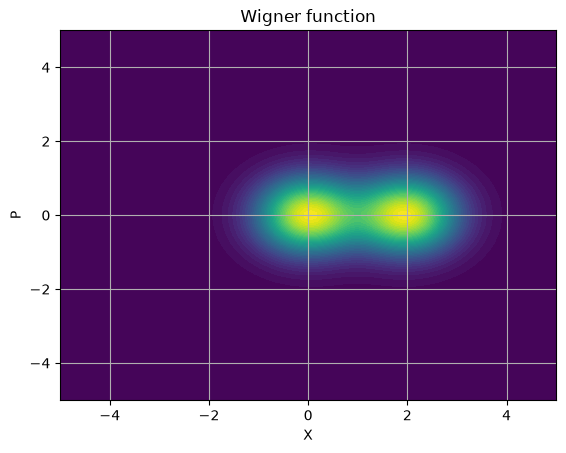

In [4]:
displace_alpha = qt.displace(N, alpha)
coherent_state1_displaced = displace_alpha * coherent_state1
coherent_state2_displaced = displace_alpha * coherent_state2
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()


In [36]:
def extract_alpha(coherent_state):
    a = qt.destroy(N)
    extracted_alpha = (coherent_state.dag() * a * coherent_state)
    return extracted_alpha

def kennedy_receiver(coherent1, coherent2):
    #extract alpha from coherent state
    alpha1 = extract_alpha(coherent1)
    alpha2 = extract_alpha(coherent2)
    #displace states by -alpha1
    displaced1 = qt.displace(N, -alpha1) * coherent1
    displaced2 = qt.displace(N, -alpha1) * coherent2
    #vacuum state
    vac_projector = qt.fock_dm(N, 0)
    prob_of_zero1 = qt.expect(vac_projector, displaced1)
    prob_of_zero2 = qt.expect(vac_projector, displaced2)
    prob_of_one1 = 1 - prob_of_zero1
    prob_of_one2 = 1 - prob_of_zero2
    #plot the before displacement and after displacement states in phase space
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    before = coherent1 + coherent2
    after = displaced1 + displaced2
    print(type(alpha1))
    maxR = np.max([alpha1.real, alpha2.real])
    maxI = np.max([alpha1.imag, alpha2.imag])
    plot_ranges_from_alpha = max(maxR, maxI)
    if plot_ranges_from_alpha < 0:
        plot_ranges_from_alpha -= 2
    elif plot_ranges_from_alpha > 0:
        plot_ranges_from_alpha += 2
    before_wigner = qt.wigner(before, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    after_wigner = qt.wigner(after, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    ax1.contourf(np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), before_wigner, 50)
    ax1.set_title('Wigner Function - Before Displacement')
    ax1.set_xlabel('X')
    ax1.set_ylabel('P')
    ax2.contourf(np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), after_wigner, 50)
    ax2.set_title('Wigner Function - After Displacement')
    ax2.set_xlabel('X')
    ax2.set_ylabel('P')
    ax1.grid()
    ax2.grid()
    print("After displacement:")
    print(f"If state 1 was sent, the probability of detecting a photon is: {prob_of_one1:.4f}")
    print(f"If state 2 was sent, the probability of detecting a photon is: {prob_of_one2:.4f}")



<class 'complex'>
After displacement:
If state 1 was sent, the probability of detecting a photon is: -0.0000
If state 2 was sent, the probability of detecting a photon is: 1.0000


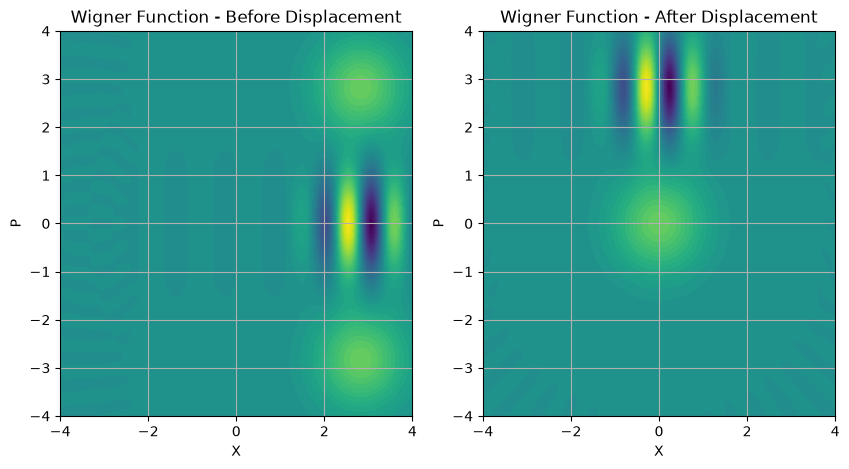

In [39]:
N = 50
alpha1 = 2 - 2j
alpha2 = 2 + 2j
coherent1 = qt.coherent(N, alpha1)
coherent2 = qt.coherent(N, alpha2)
kennedy_receiver(coherent1, coherent2)